# Step 1: Import Libraries

In [1]:
# -------------------------------------------------------
# Import required libraries
# -------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download stock data
import yfinance as yf

# ADF Test
from statsmodels.tsa.stattools import adfuller

# Plot ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

# Model Evaluation
from sklearn.metrics import mean_squared_error

# Square root calculation
from math import sqrt

# Step 2: Download Data

In [19]:
# -------------------------------------------------------
# Download Apple stock prices from Yahoo Finance
# -------------------------------------------------------

df = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2022-01-01",
    auto_adjust=True
)

# Keep only Closing Price
df = df[['Close']]

# Remove missing values
df.dropna(inplace=True)

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2020-01-02  72.333870
2020-01-03  71.630638
2020-01-06  72.201393
2020-01-07  71.861847
2020-01-08  73.017838


# Step 3: Plot Original Data

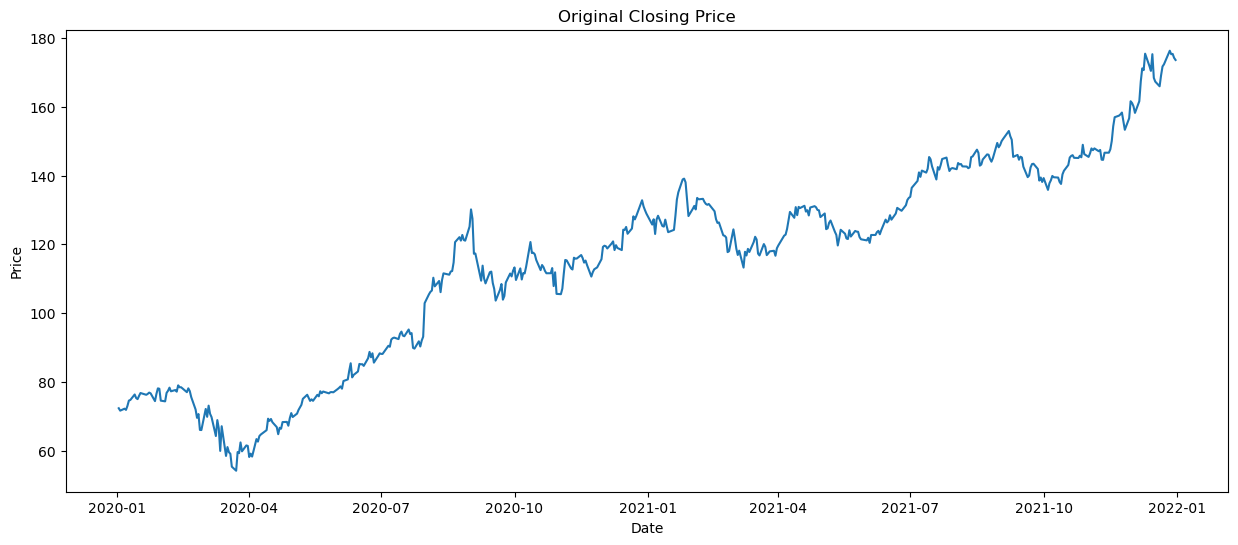

In [20]:
# -------------------------------------------------------
# Plot Original Time Series
# -------------------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(df['Close'])

plt.title("Original Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

#  Step 4: ADF Test Function

In [21]:
# -------------------------------------------------------
# Function to perform ADF Test
# -------------------------------------------------------

def adf_test(series):

    result = adfuller(series)

    print("ADF Statistic :", result[0])

    print("P-value :", result[1])

    print()

    if result[1] <= 0.05:
        print("Reject Null Hypothesis")

        print("Data is Stationary")

    else:
        print("Fail to Reject Null Hypothesis")

        print("Data is NOT Stationary")

# Step 5: Check Stationarity

In [22]:
# -------------------------------------------------------
# Check if original data is stationary
# -------------------------------------------------------

adf_test(df['Close'])

ADF Statistic : -0.23233990417984682
P-value : 0.9345553912671025

Fail to Reject Null Hypothesis
Data is NOT Stationary


# Step 6: Make Data Stationary

In [23]:
# -------------------------------------------------------
# First Order Differencing
#
# Difference = Today's Price - Yesterday's Price
# -------------------------------------------------------

df['Close_diff'] = df['Close'].diff()

# Remove first NaN created by differencing
df.dropna(inplace=True)

# Step 7: Check Again

In [24]:
# -------------------------------------------------------
# Check Stationarity after Differencing
# -------------------------------------------------------

adf_test(df['Close_diff'])

ADF Statistic : -25.023747832228995
P-value : 0.0

Reject Null Hypothesis
Data is Stationary


# Step 8: Plot Stationary Data

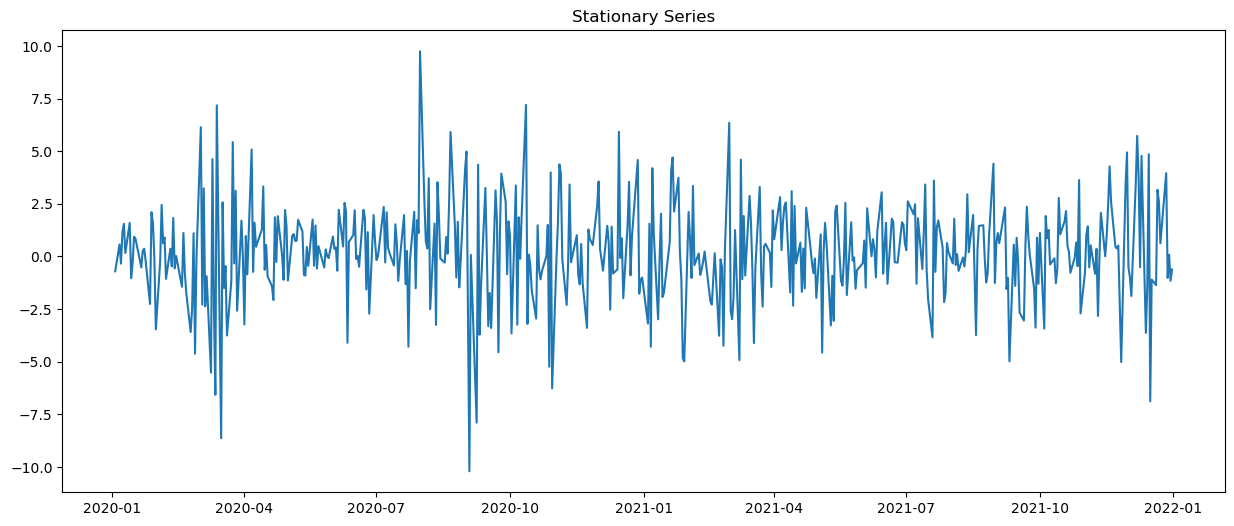

In [25]:
# -------------------------------------------------------
# Plot Differenced Series
# -------------------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(df['Close_diff'])

plt.title("Stationary Series")

plt.show()

# Step 9: Plot ACF

<Figure size 1200x600 with 0 Axes>

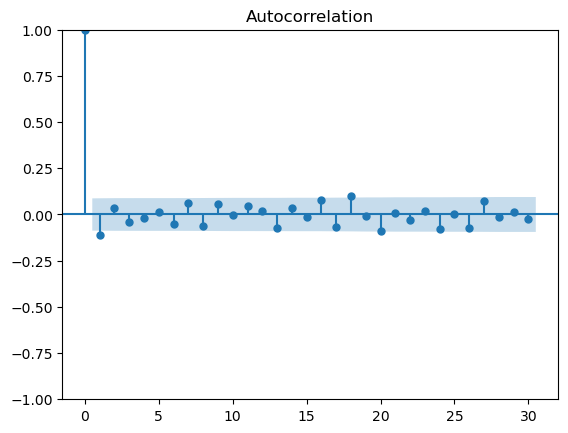

In [26]:
# -------------------------------------------------------
# ACF Plot
#
# Used to estimate q (MA order)
#
# Each bar represents the correlation between the current
# value and a previous lag.
#
# Blue shaded area = 95% Confidence Interval
#
# Bars outside the blue area are statistically significant.
# -------------------------------------------------------

plt.figure(figsize=(12,6))

plot_acf(df['Close_diff'],
         lags=30)

plt.show()

# Step 10: Plot PACF

<Figure size 1200x600 with 0 Axes>

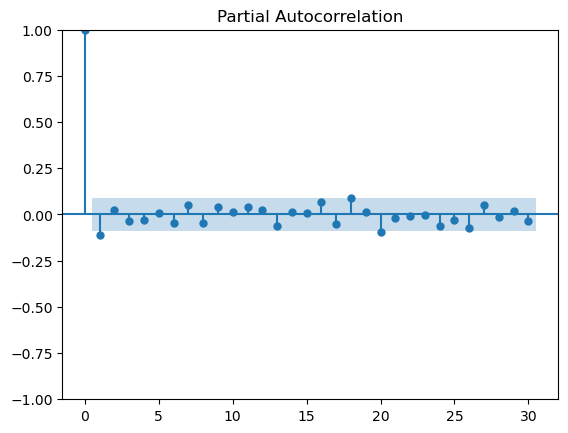

In [27]:
# -------------------------------------------------------
# PACF Plot
#
# Used to estimate p (AR order)
#
# Each bar represents the direct correlation after removing
# the effect of shorter lags.
#
# Blue shaded area = 95% Confidence Interval
#
# Significant spikes help estimate p.
# -------------------------------------------------------

plt.figure(figsize=(12,6))

plot_pacf(df['Close_diff'],
          lags=30,
          method='ywm')

plt.show()

# Step 12: Train/Test Split

In [28]:
# -------------------------------------------------------
# Use first 80% for training
# Last 20% for testing
# -------------------------------------------------------

train_size = int(len(df) * 0.80)

train = df['Close'][:train_size]

test = df['Close'][train_size:]

# Step 13: Build ARIMA

In [29]:
# -------------------------------------------------------
# Build ARIMA Model
#
# p = PACF
#
# d = Differencing
#
# q = ACF
# -------------------------------------------------------

model = ARIMA(train,
              order=(2,1,1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  403
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -914.790
Date:                Mon, 13 Jul 2026   AIC                           1837.581
Time:                        10:09:16   BIC                           1853.567
Sample:                             0   HQIC                          1843.910
                                - 403                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3640      0.991     -0.367      0.713      -2.307       1.579
ar.L2          0.0063      0.138      0.045      0.964      -0.264       0.277
ma.L1          0.2363      0.983      0.240      0.8

C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


# Step 14: Predict Test Data

In [30]:
# -------------------------------------------------------
# Predict values for the Test Set
# -------------------------------------------------------

predictions = model_fit.forecast(steps=len(test))

C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


# Step 15: Compare

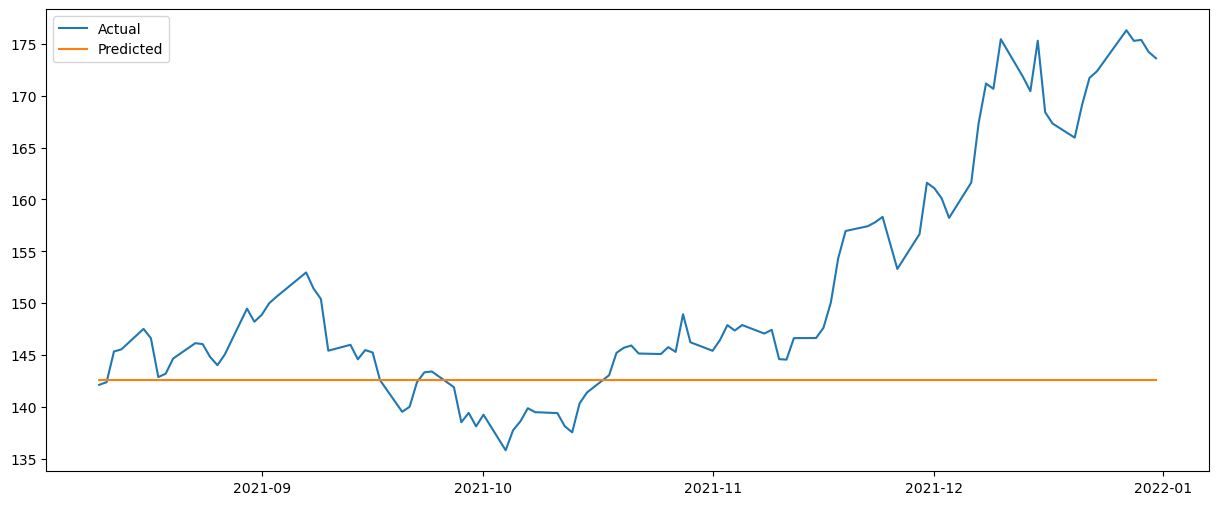

In [31]:
# -------------------------------------------------------
# Compare Actual vs Predicted
# -------------------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(test.index,
         test,
         label="Actual")

plt.plot(test.index,
         predictions,
         label="Predicted")

plt.legend()

plt.show()

# Step 16: Calculate RMSE

In [32]:
# -------------------------------------------------------
# Evaluate Prediction Error
# -------------------------------------------------------

rmse = sqrt(mean_squared_error(test,
                               predictions))

print("RMSE :", rmse)

RMSE : 13.964355245482562


# Step 17: Forecast Next 30 Days

In [17]:
# -------------------------------------------------------
# Train ARIMA on Entire Dataset
# -------------------------------------------------------

final_model = ARIMA(df['Close'],
                    order=(2,1,1))

final_fit = final_model.fit()

forecast = final_fit.forecast(30)

C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


# Step 18: Plot Forecast

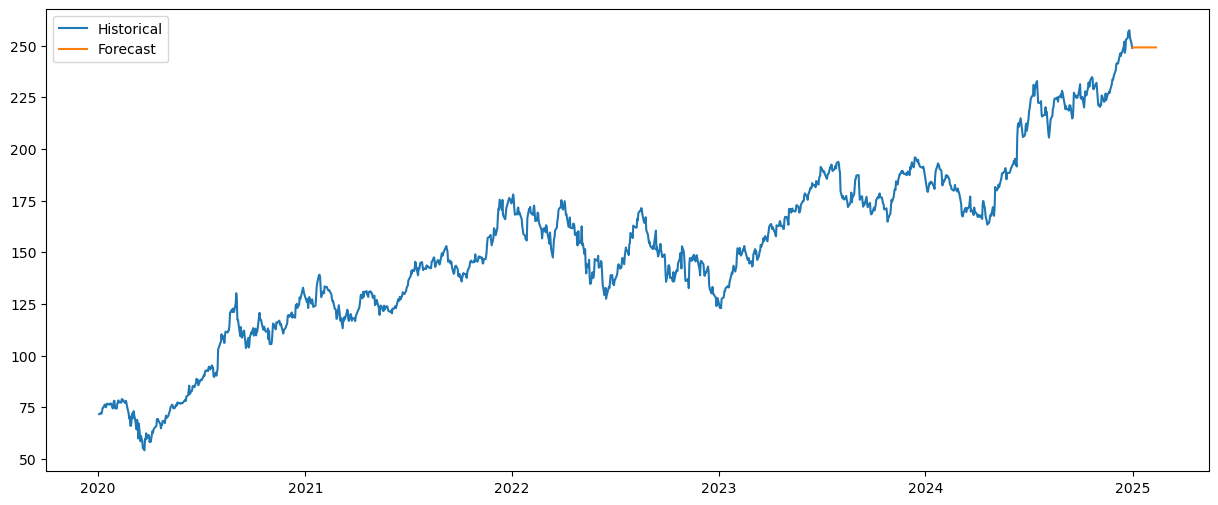

In [18]:
# -------------------------------------------------------
# Plot Historical Data + Future Forecast
# -------------------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(df.index,
         df['Close'],
         label="Historical")

future_dates = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq="B"
)[1:]

plt.plot(future_dates,
         forecast,
         label="Forecast")

plt.legend()

plt.show()